Форма DataFrame: (10000, 50)

Типы данных:
col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object

Пропуски:
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    0


C:\Users\User\AppData\Local\Temp\ipykernel_14364\1142584966.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


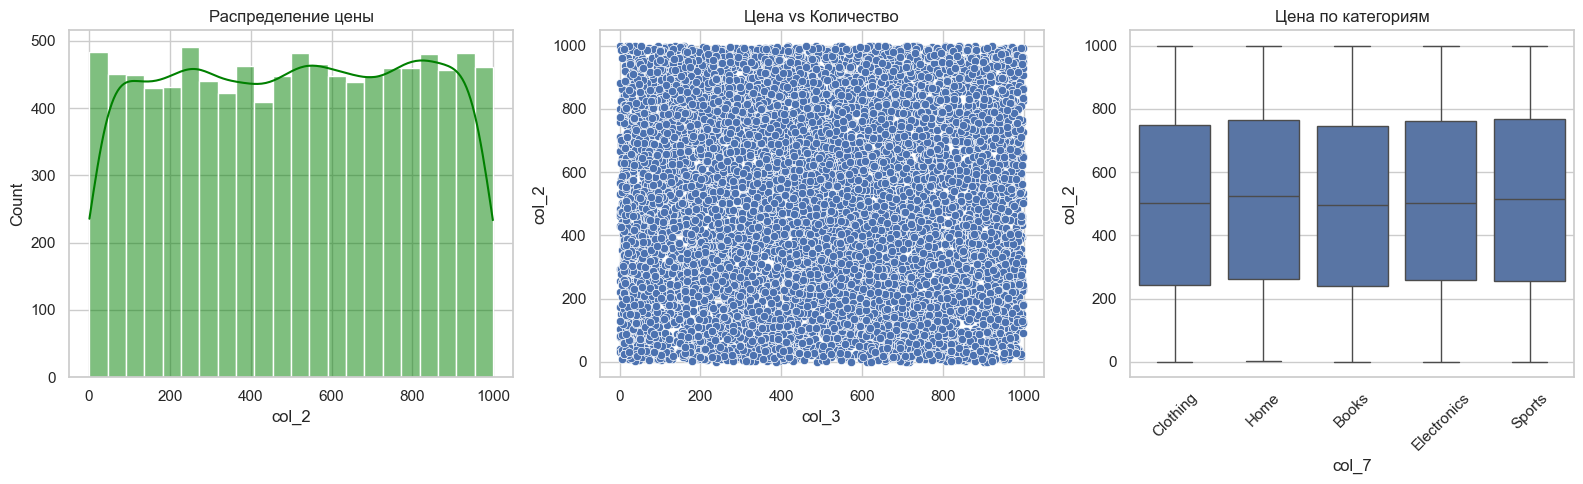


=== Задача 5: Аномалии ===
Найдено аномалий: 0
Размер данных после удаления аномалий: (10000, 53)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#1
df = pd.read_excel('catalog_products.xlsx')

print(f"Форма DataFrame: {df.shape}")
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())
print("\nПервые 5 строк:")
print(df.head())

#2

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].astype(float)
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.mean()))
text_cols = df.select_dtypes(include=['object']).columns
df = df.dropna(subset=text_cols)

#3


df['total_value'] = df['col_2'] * df['col_3']
df['log_price'] = np.log1p(df['col_2']) # log1p безопаснее, если есть нули
df['double_stock'] = df['col_3'] * 2

#4
print("\n=== Задача 4: Визуализация (откроется в новом окне) ===")

plt.figure(figsize=(16, 5))

# 1. Гистограмма цены
plt.subplot(1, 3, 1)
sns.histplot(df['col_2'], kde=True, color='green')
plt.title('Распределение цены')

# 2. Scatter plot
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='col_3', y='col_2')
plt.title('Цена vs Количество')

# 3. Boxplot (если колонка col_7 существует)
if 'col_7' in df.columns:
    plt.subplot(1, 3, 3)
    sns.boxplot(data=df, x='col_7', y='col_2')
    plt.xticks(rotation=45)
    plt.title('Цена по категориям')

plt.tight_layout()
plt.show()

#5
print("\n=== Задача 5: Аномалии ===")

mean_p = df['col_2'].mean()
std_p = df['col_2'].std()

lower_bound = mean_p - 3 * std_p
upper_bound = mean_p + 3 * std_p

anomalies = df[(df['col_2'] < lower_bound) | (df['col_2'] > upper_bound)]
df_cleaned = df[(df['col_2'] >= lower_bound) & (df['col_2'] <= upper_bound)]

print(f"Найдено аномалий: {len(anomalies)}")
print(f"Размер данных после удаления аномалий: {df_cleaned.shape}")

In [ ]:
#1
df = pd.read_excel('catalog_products.xlsx')

print(f"Форма DataFrame: {df.shape}")
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:")
print(df.isnull().sum())
print("\nПервые 5 строк:")
print(df.head())

In [ ]:
#2

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].astype(float)
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.mean()))
text_cols = df.select_dtypes(include=['object']).columns
df = df.dropna(subset=text_cols)

In [ ]:
#3


df['total_value'] = df['col_2'] * df['col_3']
df['log_price'] = np.log1p(df['col_2']) # log1p безопаснее, если есть нули
df['double_stock'] = df['col_3'] * 2

In [ ]:
#4
print("\n=== Задача 4: Визуализация (откроется в новом окне) ===")

plt.figure(figsize=(16, 5))

# 1. Гистограмма цены
plt.subplot(1, 3, 1)
sns.histplot(df['col_2'], kde=True, color='green')
plt.title('Распределение цены')

# 2. Scatter plot
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='col_3', y='col_2')
plt.title('Цена vs Количество')

# 3. Boxplot (если колонка col_7 существует)
if 'col_7' in df.columns:
    plt.subplot(1, 3, 3)
    sns.boxplot(data=df, x='col_7', y='col_2')
    plt.xticks(rotation=45)
    plt.title('Цена по категориям')

plt.tight_layout()
plt.show()

In [ ]:
#5
print("\n=== Задача 5: Аномалии ===")

mean_p = df['col_2'].mean()
std_p = df['col_2'].std()

lower_bound = mean_p - 3 * std_p
upper_bound = mean_p + 3 * std_p

anomalies = df[(df['col_2'] < lower_bound) | (df['col_2'] > upper_bound)]
df_cleaned = df[(df['col_2'] >= lower_bound) & (df['col_2'] <= upper_bound)]

print(f"Найдено аномалий: {len(anomalies)}")
print(f"Размер данных после удаления аномалий: {df_cleaned.shape}")